# Pre-processing: World Bank WDI indicators

Build the model's country indicators file from World Bank Development Indicators (WDI): GDP per capita plus a 4-class sanitation breakdown derived from the WASH indicators, for one country.

Like `1_worldpop_pre_processing.ipynb` and `2_ghs_smod_pre_processing.ipynb`, the model input is produced by **a single call** — here `get_country_indicators(country_code, output_path)`, which fetches WDI and writes `{country}_indicators.toml` directly (see section 6). WDI is **country-level tabular data**, so there is no spatial AOI; we use **Suriname (SUR)** to match the Paramaribo framing of the other notebooks.

Sections 3–5 are an **optional** detour: they download the raw WDI table to a CSV and visualise it, which is handy for sanity-checking the underlying numbers but is not needed to produce the model file.

## 1. Imports

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from d_health import (
    WDIConfig,
    build_from_wdi,
    get_country_indicators,
    get_world_bank_data,
)

c:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\.pixi\envs\default\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. Configure the run

Pick the country (ISO3) and output directory. `WDIConfig` defaults to a 10-indicator selection: GDP per capita (current USD) plus the WASH triplet (open-defecation, basic sanitation, safely-managed sanitation) in their total / rural / urban breakdowns. The default CSV separator is `;`.

In [2]:
output_dir = Path("./data")
country_code = "SUR"  # Suriname (Paramaribo is its capital)

# Date-stamp the filename so re-running on a different day doesn't overwrite yesterday's pull.
csv_path = output_dir / f"wdi_{date.today():%Y-%m-%d}.csv"

cfg = WDIConfig()  # GDP + WASH indicators, ';' separator
cfg

WDIConfig(indicator_codes=('NY.GDP.PCAP.CD', 'SH.STA.ODFC.ZS', 'SH.STA.ODFC.RU.ZS', 'SH.STA.ODFC.UR.ZS', 'SH.STA.BASS.ZS', 'SH.STA.BASS.RU.ZS', 'SH.STA.BASS.UR.ZS', 'SH.STA.SMSS.ZS', 'SH.STA.SMSS.RU.ZS', 'SH.STA.SMSS.UR.ZS'), csv_sep=';')

## 3. Fetch and filter

`get_world_bank_data` streams the WDI ZIP from the World Bank DataBank into a temp directory, extracts `WDICSV.csv`, keeps only the selected indicators, and saves one row per `(country, indicator)` with the most recent non-null value (and the year it came from). The ZIP and the full WDI CSV are removed before the call returns — only the filtered CSV lands at `csv_path`.

In [3]:
get_world_bank_data(csv_path, cfg=cfg)
csv_path

d_health.preprocessing.world_bank | INFO | WDI fetch via wbgapi — 10 indicators
d_health.preprocessing.world_bank | INFO | Received 2133 rows across 264 economies x 10 indicators
d_health.preprocessing.world_bank | INFO | Wrote wdi_2026-07-02.csv (2133 rows, 0.25 MB)


WindowsPath('data/wdi_2026-07-02.csv')

## 4. Inspect the output

Load the filtered CSV and slice it to Suriname. There should be one row per indicator in `cfg.indicator_codes` (some indicators may be missing if WDI never reported them for SUR).

In [4]:
df = pd.read_csv(csv_path, sep=cfg.csv_sep)
print(f"Total rows:    {len(df):,}")
print(f"Countries:     {df['Country Code'].nunique()}")
print(f"Indicators:    {df['Indicator Code'].nunique()}")

sur = (
    df[df["Country Code"] == country_code]
    .sort_values("Indicator Code")
    .reset_index(drop=True)
)
missing = set(cfg.indicator_codes) - set(sur["Indicator Code"])
if missing:
    print(f"\nMissing for {country_code}: {sorted(missing)}")
sur

Total rows:    2,133
Countries:     264
Indicators:    10


,Country Name,Country Code,Indicator Name,Indicator Code,Latest Year,Latest Value
0,Suriname,SUR,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,7069.872309
1,Suriname,SUR,People using at least basic sanitation service...,SH.STA.BASS.RU.ZS,2024,82.364078
2,Suriname,SUR,People using at least basic sanitation service...,SH.STA.BASS.UR.ZS,2024,93.838376
3,Suriname,SUR,People using at least basic sanitation service...,SH.STA.BASS.ZS,2024,89.998275
4,Suriname,SUR,"People practicing open defecation, rural (% of...",SH.STA.ODFC.RU.ZS,2024,3.246850
5,Suriname,SUR,"People practicing open defecation, urban (% of...",SH.STA.ODFC.UR.ZS,2024,0.182121
6,Suriname,SUR,People practicing open defecation (% of popula...,SH.STA.ODFC.ZS,2024,1.207794
7,Suriname,SUR,People using safely managed sanitation service...,SH.STA.SMSS.RU.ZS,2024,33.948910
8,Suriname,SUR,People using safely managed sanitation service...,SH.STA.SMSS.UR.ZS,2024,20.693521
9,Suriname,SUR,People using safely managed sanitation service...,SH.STA.SMSS.ZS,2024,25.129703


## 5. Visualise

GDP per capita and the WASH indicators have different units (USD vs % of population), so we split them across two axes. Each bar is labelled with the year the value comes from, since the "latest available year" varies by indicator.

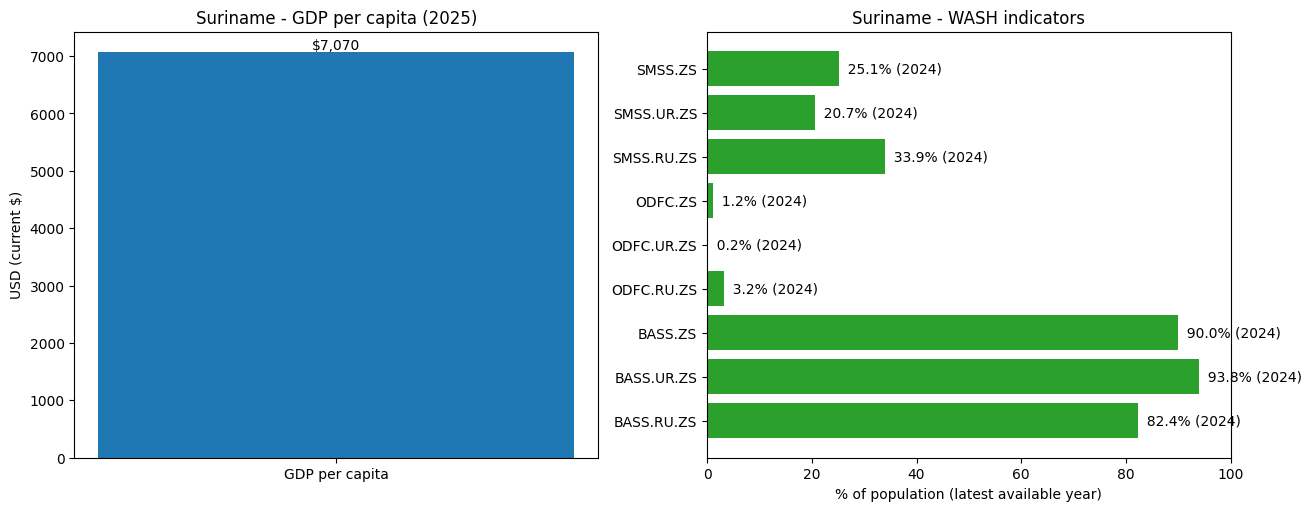

In [5]:
gdp = sur[sur["Indicator Code"] == "NY.GDP.PCAP.CD"]
wash = sur[sur["Indicator Code"] != "NY.GDP.PCAP.CD"].copy()
# Short label, e.g. 'SH.STA.ODFC.RU.ZS' -> 'ODFC.RU.ZS'
wash["Short"] = wash["Indicator Code"].str.replace("SH.STA.", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

if not gdp.empty:
    val = float(gdp["Latest Value"].iloc[0])
    yr = int(gdp["Latest Year"].iloc[0])
    axes[0].bar(["GDP per capita"], [val], color="#1f77b4")
    axes[0].set_ylabel("USD (current $)")
    axes[0].set_title(f"Suriname - GDP per capita ({yr})")
    axes[0].text(0, val, f"${val:,.0f}", ha="center", va="bottom")
else:
    axes[0].set_axis_off()
    axes[0].set_title("GDP per capita: no data")

axes[1].barh(wash["Short"], wash["Latest Value"], color="#2ca02c")
axes[1].set_xlabel("% of population (latest available year)")
axes[1].set_title("Suriname - WASH indicators")
axes[1].set_xlim(0, 100)
for short, value, year in zip(wash["Short"], wash["Latest Value"], wash["Latest Year"]):
    axes[1].text(value, short, f"  {value:.1f}% ({int(year)})", va="center")

plt.show()

## 6. Build the country indicators TOML — one call

This is the actual model input. **`get_country_indicators` does it in a single call** — like `get_population_data` and `get_smod_data` in the other notebooks: it fetches the WDI values, derives GDP per capita + the 4-class sanitation breakdown (Safe / Advanced / Basic / None, per urban and rural), and writes `{country}_indicators.toml`. **Sections 3–5 above are optional** — they just download and explore the raw WDI table; you don't need the CSV to produce the model file.

If you already pulled a WDI CSV (section 3) and want to derive the TOML from it without re-fetching, use `build_from_wdi(csv_path, country_code, out_path)` instead. If you have indicator values from a different source, write a TOML matching the schema in `d_health/config/emissions.py::CountryIndicators`.

In [6]:
indicators_path = output_dir / f"{country_code.lower()}_indicators.toml"

# One call: fetch WDI + derive + write the model's indicators TOML.
get_country_indicators(country_code, indicators_path)
print(indicators_path.read_text())

d_health.preprocessing.world_bank | INFO | WDI fetch via wbgapi — 10 indicators
d_health.preprocessing.world_bank | INFO | Received 2133 rows across 264 economies x 10 indicators
d_health.preprocessing.country_indicators | INFO | Wrote data\sur_indicators.toml (GDP=7070, Safe u/r=20.7/33.9, None u/r=0.2/3.2)


country_code   = "SUR"
gdp_per_capita = 7069.87230892274

# WB-derived 4-class sanitation breakdown (percent, sums to 100 per column).
[[sanitation]]
name  = "Safe"
urban = 20.6935
rural = 33.9489
[[sanitation]]
name  = "Advanced"
urban = 73.1449
rural = 48.4152
[[sanitation]]
name  = "Basic"
urban = 5.9795
rural = 14.3891
[[sanitation]]
name  = "None"
urban = 0.1821
rural = 3.2468

